# FIO iod-bs sweep: multi-run stability analysis

Multiple runs per `(bs, iod)` configuration (each run = independent fio job with a fresh dataset).

**Block sizes:** 4k, 16k, 1m, 2m, 4m  
**Queue depths (iodepth):** 4, 8, 16, 32, 64, 128, 256

## Sequential Read

In [1]:
import json, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "."

records = []
skipped = []
for f in sorted(glob.glob(f"{DATA_DIR}/fio_seq_read_*.json")):
    m = re.match(r".*/fio_seq_read_(bs\w+)_nj1_(iod\d+)_(\d+)\.json", f)
    if not m:
        continue
    bs, iod, ts = m.group(1), m.group(2), m.group(3)
    try:
        with open(f) as fh:
            d = json.load(fh)
        r = d['jobs'][0]['read']
        records.append({
            'bs': bs, 'iod': iod, 'ts': ts,
            'bw_GiBs': r['bw_bytes'] / 2**30,
            'iops': r['iops'],
            'lat_ms': r['lat_ns']['mean'] / 1e6,
        })
    except (json.JSONDecodeError, KeyError) as e:
        skipped.append((f, str(e)))

df = pd.DataFrame(records)

BS_ORDER  = ['bs4k', 'bs16k', 'bs1m', 'bs2m', 'bs4m']
IOD_ORDER = ['iod4', 'iod8', 'iod16', 'iod32', 'iod64', 'iod128', 'iod256']
df['bs']  = pd.Categorical(df['bs'],  categories=BS_ORDER,  ordered=True)
df['iod'] = pd.Categorical(df['iod'], categories=IOD_ORDER, ordered=True)
df['iod_n'] = df['iod'].str.replace('iod', '').astype(int)
df = df.sort_values(['bs', 'iod', 'ts']).reset_index(drop=True)

print(f"Total records: {len(df)}")
if skipped:
    print(f"Skipped {len(skipped)} files:")
    for f, e in skipped:
        print(f"  {f}: {e}")
print("\nRuns per (bs, iod):")
print(df.groupby(['bs', 'iod'], observed=True).size().unstack('iod').to_string())

Total records: 29

Runs per (bs, iod):
iod    iod4  iod8  iod16  iod32  iod64  iod128  iod256
bs                                                    
bs4k    1.0   1.0    1.0    1.0    1.0     1.0     1.0
bs16k   1.0   1.0    1.0    1.0    1.0     1.0     1.0
bs1m    1.0   1.0    1.0    1.0    1.0     1.0     1.0
bs2m    1.0   1.0    1.0    1.0    1.0     1.0     1.0
bs4m    1.0   NaN    NaN    NaN    NaN     NaN     NaN


In [2]:
# --- Multi-run stats per (bs, iod): mean, std, CV, min, max ---
stats = (
    df.groupby(['bs', 'iod'], observed=True)['bw_GiBs']
    .agg(
        n_runs='count',
        median='median',
        std='std',
        cv_pct=lambda x: x.std() / x.mean() * 100 if len(x) > 1 else float('nan'),
        min='min',
        max='max',
    )
    .reset_index()
)
stats['spread'] = stats['max'] - stats['min']

pd.set_option('display.float_format', '{:.2f}'.format)
print("BW (GiB/s) statistics across runs per (bs, iod):")
display(stats)


BW (GiB/s) statistics across runs per (bs, iod):


,bs,iod,n_runs,median,std,cv_pct,min,max,spread
0,bs4k,iod4,1,0.10,NaN,NaN,0.10,0.10,0.00
1,bs4k,iod8,1,0.14,NaN,NaN,0.14,0.14,0.00
2,bs4k,iod16,1,0.18,NaN,NaN,0.18,0.18,0.00
3,bs4k,iod32,1,0.27,NaN,NaN,0.27,0.27,0.00
4,bs4k,iod64,1,0.31,NaN,NaN,0.31,0.31,0.00
5,bs4k,iod128,1,0.40,NaN,NaN,0.40,0.40,0.00
6,bs4k,iod256,1,0.39,NaN,NaN,0.39,0.39,0.00
7,bs16k,iod4,1,0.25,NaN,NaN,0.25,0.25,0.00
8,bs16k,iod8,1,0.46,NaN,NaN,0.46,0.46,0.00
9,bs16k,iod16,1,0.84,NaN,NaN,0.84,0.84,0.00


In [3]:
cv_range_sr = (
    stats.groupby("bs", observed=True)["cv_pct"]
    .agg(cv_min="min", cv_max="max")
    .reset_index()
)
print("Sequential Read CV (%) range per block size:")
display(cv_range_sr)

Sequential Read CV (%) range per block size:


,bs,cv_min,cv_max
0,bs4k,NaN,NaN
1,bs16k,NaN,NaN
2,bs1m,NaN,NaN
3,bs2m,NaN,NaN
4,bs4m,NaN,NaN


In [4]:
bw_range_sr = (
    stats.groupby("bs", observed=True)["median"]
    .agg(bw_min="min", bw_max="max")
    .reset_index()
)
print("Sequential Read BW (GiB/s) range per block size (across iodepths):")
display(bw_range_sr)

Sequential Read BW (GiB/s) range per block size (across iodepths):


,bs,bw_min,bw_max
0,bs4k,0.10,0.40
1,bs16k,0.25,1.52
2,bs1m,3.26,12.24
3,bs2m,3.28,20.71
4,bs4m,3.18,3.18


In [5]:
# --- Bimodal mode detection: ceiling (~3.5 GiB/s) vs high-BW per run ---
CEILING_THRESH = 4.2  # GiB/s — below this = serialized-IO mode

df['mode'] = df['bw_GiBs'].apply(lambda x: 'ceiling' if x < CEILING_THRESH else 'parallel')

mode_stats = (
    df.groupby(['bs', 'iod'], observed=True)
    .apply(lambda g: pd.Series({
        'n_runs':       len(g),
        'n_ceiling':    (g['mode'] == 'ceiling').sum(),
        'n_parallel':   (g['mode'] == 'parallel').sum(),
        'pct_ceiling':  (g['mode'] == 'ceiling').mean() * 100,
        'mean_ceiling': g.loc[g['mode'] == 'ceiling', 'bw_GiBs'].mean(),
        'mean_parallel':g.loc[g['mode'] == 'parallel', 'bw_GiBs'].mean(),
    }), include_groups=False)
    .reset_index()
)

# mode_stats


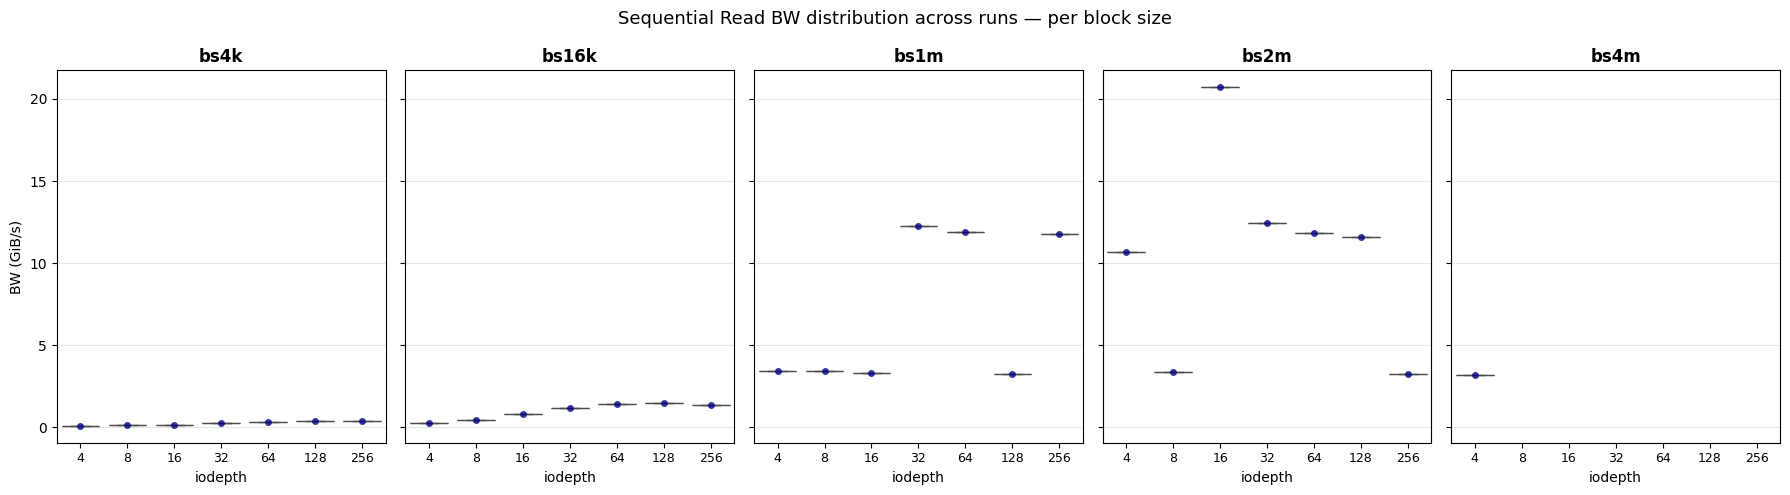

In [6]:
# --- BW distribution: 5 box plots, one per block size ---
IOD_NUMS = [int(i.replace('iod', '')) for i in IOD_ORDER]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)

for ax, bs in zip(axes, BS_ORDER):
    sub = df[df['bs'] == bs].copy()
    sub['iod_n'] = sub['iod_n'].astype(int)

    sns.boxplot(
        data=sub, x='iod_n', y='bw_GiBs',
        order=IOD_NUMS,
        ax=ax, color='steelblue', linewidth=0.9,
        fliersize=0,   # hide default outlier markers; strip plot handles points
    )
    # overlay individual run points
    sns.stripplot(
        data=sub, x='iod_n', y='bw_GiBs',
        order=IOD_NUMS,
        ax=ax, size=5, color='navy', alpha=0.8, jitter=False,
    )

    ax.set_title(bs, fontweight='bold')
    ax.set_xlabel('iodepth')
    ax.set_ylabel('BW (GiB/s)' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Sequential Read BW distribution across runs — per block size', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_seqread_bw.pdf', bbox_inches='tight')
plt.show()

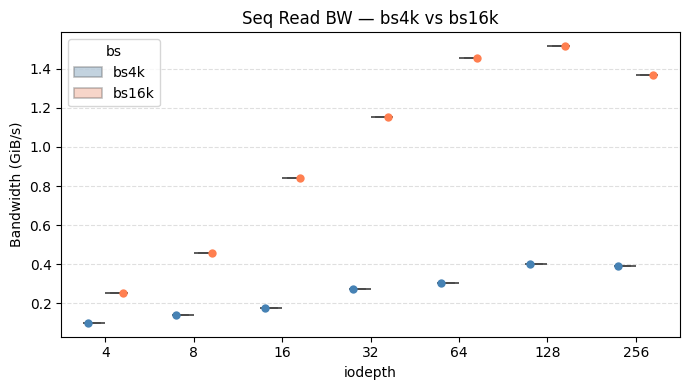

In [7]:
# --- 4k and 16k BW in one chart ---
sub_small = df[df["bs"].isin(["bs4k", "bs16k"])].copy()
sub_small["bs"] = sub_small["bs"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(7, 4))

palette = {"bs4k": "steelblue", "bs16k": "coral"}

sns.boxplot(
    data=sub_small, x="iod_n", y="bw_GiBs", hue="bs",
    order=IOD_NUMS, hue_order=["bs4k", "bs16k"],
    palette=palette, width=0.5, fliersize=0, linewidth=1.2,
    boxprops=dict(alpha=0.35), ax=ax,
)
sns.stripplot(
    data=sub_small, x="iod_n", y="bw_GiBs", hue="bs",
    order=IOD_NUMS, hue_order=["bs4k", "bs16k"],
    palette=palette, size=6, jitter=False, dodge=True,
    legend=False, ax=ax,
)

ax.set_xlabel("iodepth")
ax.set_ylabel("Bandwidth (GiB/s)")
ax.set_title("Seq Read BW — bs4k vs bs16k")
ax.legend(title="bs")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Findings

**CV heatmap (run-to-run variability):**
- Small block sizes (4k, 16k): CV is low across all iodepths — reproducible.
- Large block sizes (1m, 2m, 4m): high CV at many (bs, iod) cells, driven by the bimodal ceiling/parallel split. A cell with 50% ceiling + 50% parallel runs will have very high CV.

**Ceiling-mode heatmap:**
- Identifies which (bs, iod) cells are non-deterministically entering the ~3.5 GiB/s serialized-IO mode.
- Cells with 0% ceiling are reliably in the parallel (high-BW) regime.
- Cells with 100% ceiling are stuck in serialized mode regardless of run.
- Cells with mixed % represent the non-deterministic regime — DAOS object placement at write time determines which mode is hit.

**Interpretation:** The fraction of ceiling-mode runs is a more informative signal than mean BW or CV alone for large-BS configurations. The non-determinism is attributable to DAOS stripe placement; fixing the object class (e.g., `OC_SX`) in the DFS container config would eliminate this bimodality.

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_43155/1735957926.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='upper right', framealpha=0.7)


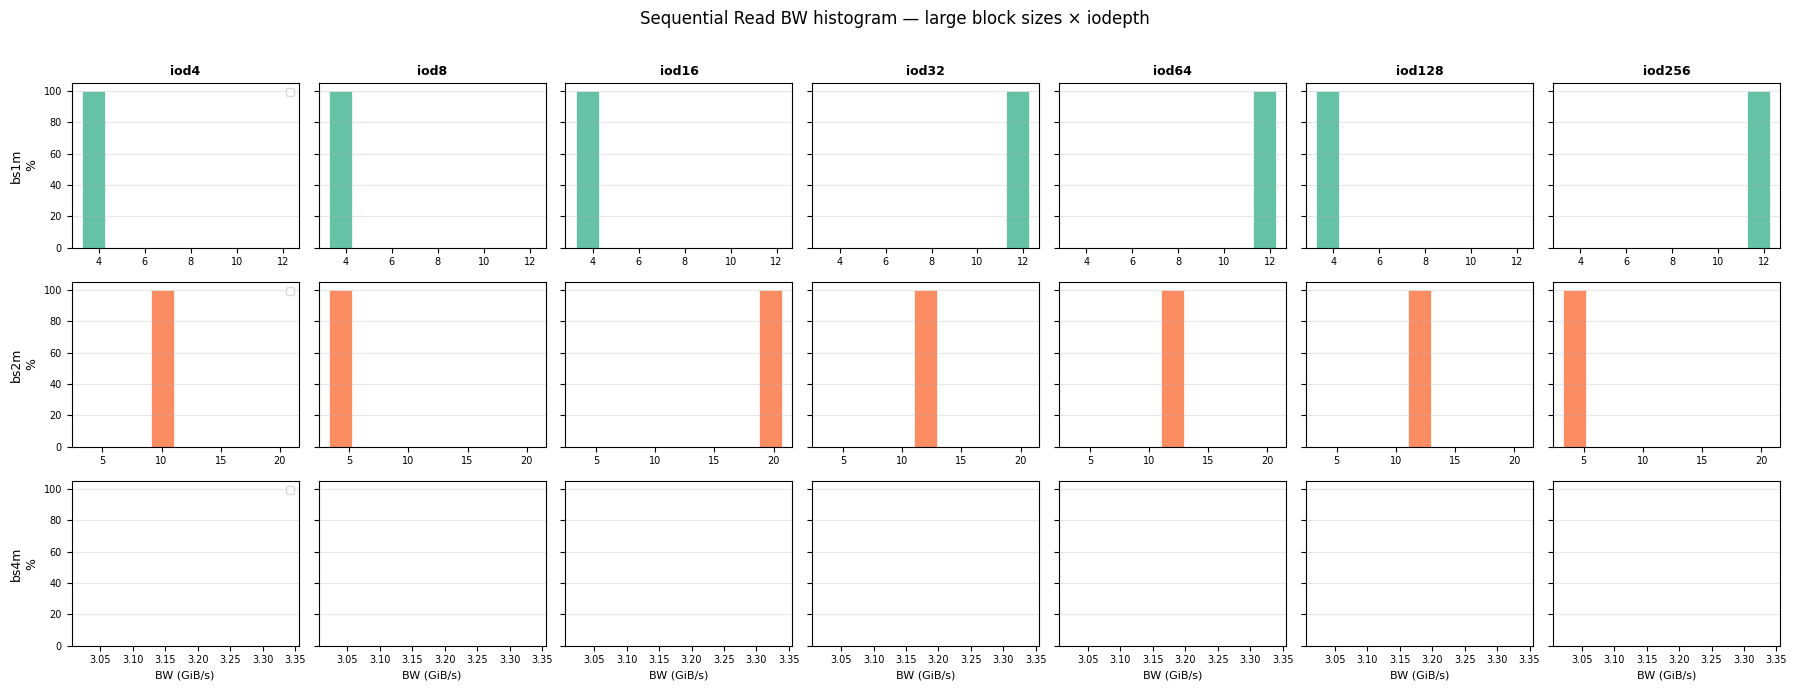

In [8]:
# --- BW histogram for larger block sizes (1m, 2m, 4m), faceted by iodepth ---
LARGE_BS  = ['bs1m', 'bs2m', 'bs4m']
IOD_NUMS  = [int(i.replace('iod', '')) for i in IOD_ORDER]
colors    = sns.color_palette("Set2", len(LARGE_BS))

fig, axes = plt.subplots(len(LARGE_BS), len(IOD_NUMS),
                         figsize=(18, 7), sharey='row', sharex='row')

for row, (bs, color) in enumerate(zip(LARGE_BS, colors)):
    bs_data = df[df['bs'] == bs]['bw_GiBs']
    bins = np.linspace(bs_data.min(), bs_data.max(), 10)  # shared bin edges across the row
    for col, iod_n in enumerate(IOD_NUMS):
        ax  = axes[row][col]
        sub = df[(df['bs'] == bs) & (df['iod_n'] == iod_n)]['bw_GiBs']
        weights = np.ones(len(sub)) / len(sub) * 100
        ax.hist(sub, bins=bins, weights=weights, color=color, edgecolor='white', linewidth=0.5)
        if col == 0:
            ax.legend(fontsize=7, loc='upper right', framealpha=0.7)
        if row == 0:
            ax.set_title(f'iod{iod_n}', fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{bs}\n%', fontsize=9)
        ax.set_xlabel('BW (GiB/s)' if row == len(LARGE_BS) - 1 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Sequential Read BW histogram — large block sizes × iodepth\n', fontsize=12)
plt.tight_layout()
plt.savefig('histogram_seqread_bw_large_bs.pdf', bbox_inches='tight')
plt.show()